In [2]:
import sys
import os

sys.path.append(os.path.abspath(".."))


In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime
from scipy import stats
from module.plotMissingValues import percentage as pmv

In [4]:
Customers_data = pd.read_csv("D:/STUDIES/Projects/Data Analysis/Brazilian E-commerce Data Analysis/Data/Raw/olist_customers_dataset.csv")
Geo = pd.read_csv("D:/STUDIES/Projects/Data Analysis/Brazilian E-commerce Data Analysis/Data/Raw/olist_geolocation_dataset.csv")
Orders = pd.read_csv("D:/STUDIES/Projects/Data Analysis/Brazilian E-commerce Data Analysis/Data/Raw/olist_orders_dataset.csv")
Order_items = pd.read_csv("D:/STUDIES/Projects/Data Analysis/Brazilian E-commerce Data Analysis/Data/Raw/olist_order_items_dataset.csv")
Payments = pd.read_csv("D:/STUDIES/Projects/Data Analysis/Brazilian E-commerce Data Analysis/Data/Raw/olist_order_payments_dataset.csv")
Reviews = pd.read_csv("D:/STUDIES/Projects/Data Analysis/Brazilian E-commerce Data Analysis/Data/Raw/olist_order_reviews_dataset.csv")
Products = pd.read_csv("D:/STUDIES/Projects/Data Analysis/Brazilian E-commerce Data Analysis/Data/Raw/olist_products_dataset.csv")
Sellers = pd.read_csv("D:/STUDIES/Projects/Data Analysis/Brazilian E-commerce Data Analysis/Data/Raw/olist_sellers_dataset.csv")
Category_name_translation = pd.read_csv("D:/STUDIES/Projects/Data Analysis/Brazilian E-commerce Data Analysis/Data/Raw/product_category_name_translation.csv")

Broad look on all data present

In [5]:
Customers_data

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP
...,...,...,...,...,...
99436,17ddf5dd5d51696bb3d7c6291687be6f,1a29b476fee25c95fbafc67c5ac95cf8,3937,sao paulo,SP
99437,e7b71a9017aa05c9a7fd292d714858e8,d52a67c98be1cf6a5c84435bd38d095d,6764,taboao da serra,SP
99438,5e28dfe12db7fb50a4b2f691faecea5e,e9f50caf99f032f0bf3c55141f019d99,60115,fortaleza,CE
99439,56b18e2166679b8a959d72dd06da27f9,73c2643a0a458b49f58cea58833b192e,92120,canoas,RS


In [6]:
Customers_data.customer_unique_id.nunique()

96096

In [7]:
Customers_data.customer_id.nunique()

99441

Total Number of customers = 96096

In [8]:
Customers_data.customer_city.nunique()

4119

In [9]:
Customers_data.customer_city

0                       franca
1        sao bernardo do campo
2                    sao paulo
3              mogi das cruzes
4                     campinas
                 ...          
99436                sao paulo
99437          taboao da serra
99438                fortaleza
99439                   canoas
99440                    cotia
Name: customer_city, Length: 99441, dtype: object

In [10]:
Geo

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP
...,...,...,...,...,...
1000158,99950,-28.068639,-52.010705,tapejara,RS
1000159,99900,-27.877125,-52.224882,getulio vargas,RS
1000160,99950,-28.071855,-52.014716,tapejara,RS
1000161,99980,-28.388932,-51.846871,david canabarro,RS


In [11]:
Geo.geolocation_city.nunique()

8011

In [12]:
Orders

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00
...,...,...,...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28 00:00:00
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02 00:00:00
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27 00:00:00
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00


In [13]:
Order_items

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14
...,...,...,...,...,...,...,...
112645,fffc94f6ce00a00581880bf54a75a037,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-05-02 04:11:01,299.99,43.41
112646,fffcd46ef2263f404302a634eb57f7eb,1,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb8314b69182,2018-07-20 04:31:48,350.00,36.53
112647,fffce4705a9662cd70adb13d4a31832d,1,72a30483855e2eafc67aee5dc2560482,c3cfdc648177fdbbbb35635a37472c53,2017-10-30 17:14:25,99.90,16.95
112648,fffe18544ffabc95dfada21779c9644f,1,9c422a519119dcad7575db5af1ba540e,2b3e4a2a3ea8e01938cabda2a3e5cc79,2017-08-21 00:04:32,55.99,8.72


In [14]:
Products

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0
...,...,...,...,...,...,...,...,...,...
32946,a0b7d5a992ccda646f2d34e418fff5a0,moveis_decoracao,45.0,67.0,2.0,12300.0,40.0,40.0,40.0
32947,bf4538d88321d0fd4412a93c974510e6,construcao_ferramentas_iluminacao,41.0,971.0,1.0,1700.0,16.0,19.0,16.0
32948,9a7c6041fa9592d9d9ef6cfe62a71f8c,cama_mesa_banho,50.0,799.0,1.0,1400.0,27.0,7.0,27.0
32949,83808703fc0706a22e264b9d75f04a2e,informatica_acessorios,60.0,156.0,2.0,700.0,31.0,13.0,20.0


In [15]:
Payments

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45
...,...,...,...,...,...
103881,0406037ad97740d563a178ecc7a2075c,1,boleto,1,363.31
103882,7b905861d7c825891d6347454ea7863f,1,credit_card,2,96.80
103883,32609bbb3dd69b3c066a6860554a77bf,1,credit_card,1,47.77
103884,b8b61059626efa996a60be9bb9320e10,1,credit_card,5,369.54


In [16]:
Reviews

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53
...,...,...,...,...,...,...,...
99219,574ed12dd733e5fa530cfd4bbf39d7c9,2a8c23fee101d4d5662fa670396eb8da,5,NaN,NaN,2018-07-07 00:00:00,2018-07-14 17:18:30
99220,f3897127253a9592a73be9bdfdf4ed7a,22ec9f0669f784db00fa86d035cf8602,5,NaN,NaN,2017-12-09 00:00:00,2017-12-11 20:06:42
99221,b3de70c89b1510c4cd3d0649fd302472,55d4004744368f5571d1f590031933e4,5,NaN,"Excelente mochila, entrega super rápida. Super...",2018-03-22 00:00:00,2018-03-23 09:10:43
99222,1adeb9d84d72fe4e337617733eb85149,7725825d039fc1f0ceb7635e3f7d9206,4,NaN,NaN,2018-07-01 00:00:00,2018-07-02 12:59:13


In [17]:
Sellers

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP
...,...,...,...,...
3090,98dddbc4601dd4443ca174359b237166,87111,sarandi,PR
3091,f8201cab383e484733266d1906e2fdfa,88137,palhoca,SC
3092,74871d19219c7d518d0090283e03c137,4650,sao paulo,SP
3093,e603cf3fec55f8697c9059638d6c8eb5,96080,pelotas,RS


In [18]:
Category_name_translation

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor
...,...,...
66,flores,flowers
67,artes_e_artesanato,arts_and_craftmanship
68,fraldas_higiene,diapers_and_hygiene
69,fashion_roupa_infanto_juvenil,fashion_childrens_clothes


Access the order_items DataFrame

In [19]:
Order_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [20]:
Order_items.isnull().sum()

order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

In [21]:
Order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [22]:
duplicates = Order_items[Order_items.duplicated()]
print(f"Number of duplicate rows: {duplicates.shape[0]}")

Number of duplicate rows: 0


In [23]:
order_lines_duplicate = Order_items[["order_id", "product_id"]].duplicated().sum()
print(f"Total duplicate value in order lines: {order_lines_duplicate}")

Total duplicate value in order lines: 10225


In [24]:
Order_items.describe()

,order_item_id,price,freight_value
count,112650.000000,112650.000000,112650.000000
mean,1.197834,120.653739,19.990320
std,0.705124,183.633928,15.806405
min,1.000000,0.850000,0.000000
25%,1.000000,39.900000,13.080000
50%,1.000000,74.990000,16.260000
75%,1.000000,134.900000,21.150000
max,21.000000,6735.000000,409.680000


In [25]:
print(Order_items.loc[Order_items["freight_value"].idxmax()])

order_id               a77e1550db865202c56b19ddc6dc4d53
order_item_id                                         1
product_id             ec31d2a17b299511e7c8627be9337b9b
seller_id              257e61d3251fb5efb9daadddbc2cf7ca
shipping_limit_date                 2018-04-25 06:55:13
price                                             979.0
freight_value                                    409.68
Name: 73486, dtype: object


<Axes: xlabel='freight_value'>

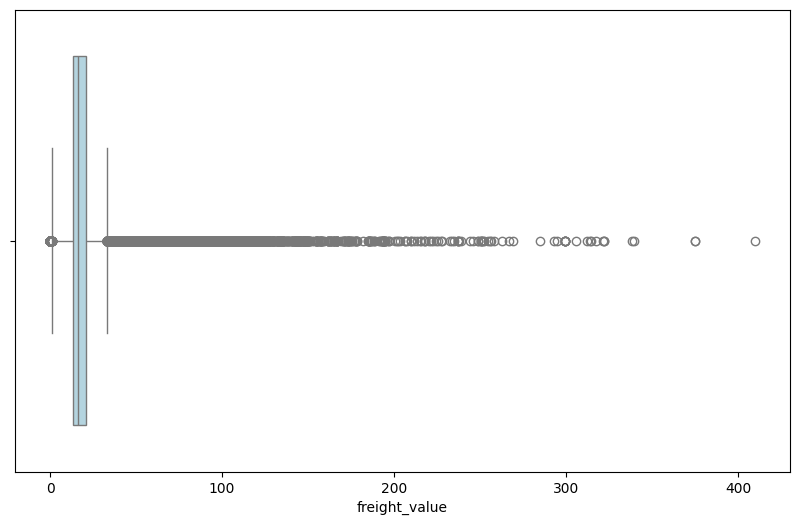

In [26]:
#boxplot freight value
plt.figure(figsize=(10,6))
sns.boxplot(x = Order_items["freight_value"], color="lightblue")

In [27]:
print(Order_items.loc[Order_items["price"].idxmax()])

order_id               0812eb902a67711a1cb742b3cdaa65ae
order_item_id                                         1
product_id             489ae2aa008f021502940f251d4cce7f
seller_id              e3b4998c7a498169dc7bce44e6bb6277
shipping_limit_date                 2017-02-16 20:37:36
price                                            6735.0
freight_value                                    194.31
Name: 3556, dtype: object


<Axes: xlabel='price'>

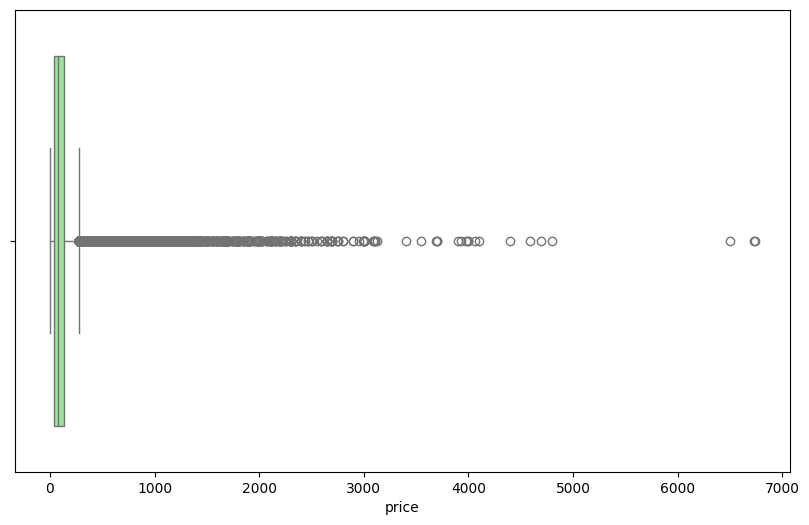

In [28]:
#boxplot of price
plt.figure(figsize=(10,6))
sns.boxplot(x = Order_items["price"], color="lightgreen")

<Axes: xlabel='price', ylabel='Count'>

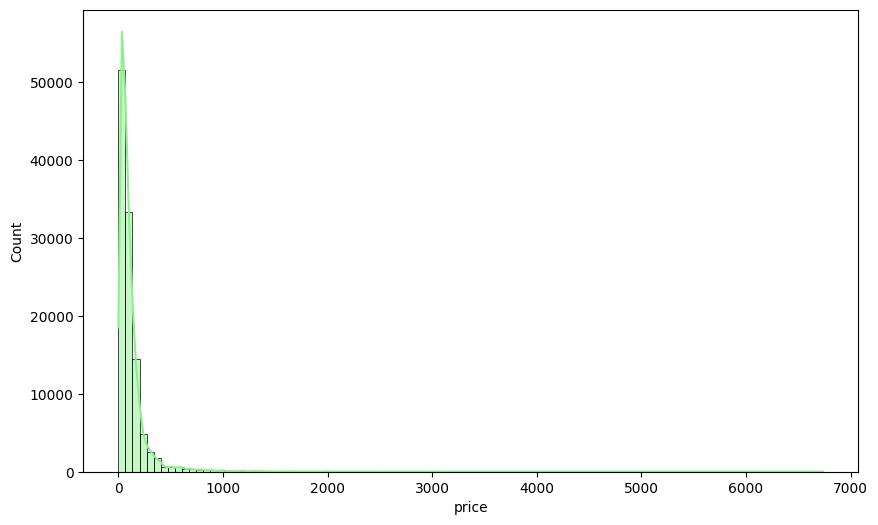

In [29]:
#Histogram of price
plt.figure(figsize=(10,6))
sns.histplot(Order_items["price"], bins=100, color="lightgreen", kde=True)

<Axes: xlabel='freight_value', ylabel='Count'>

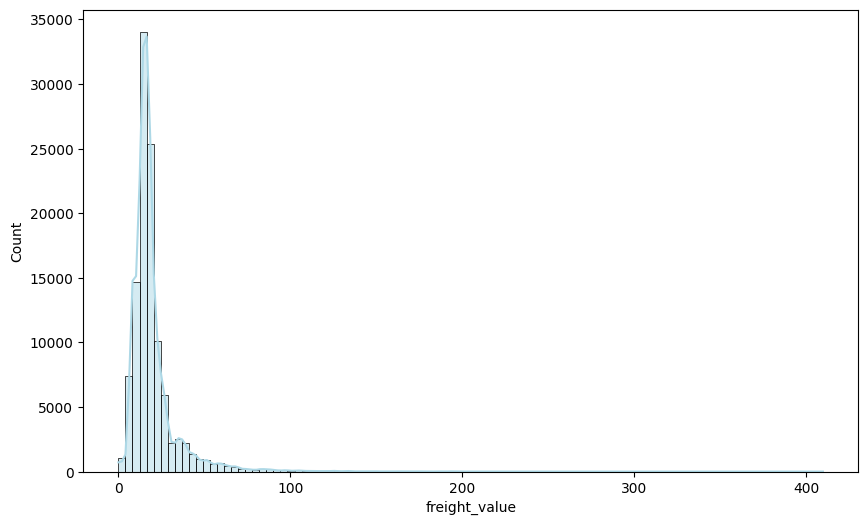

In [30]:
#histogram of freight value
plt.figure(figsize=(10,6))
sns.histplot(Order_items["freight_value"], bins=100, color="lightblue", kde=True)

Access the Payments DataFrame

In [31]:
Payments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


In [32]:
Payments.describe()

,payment_sequential,payment_installments,payment_value
count,103886.000000,103886.000000,103886.000000
mean,1.092679,2.853349,154.100380
std,0.706584,2.687051,217.494064
min,1.000000,0.000000,0.000000
25%,1.000000,1.000000,56.790000
50%,1.000000,1.000000,100.000000
75%,1.000000,4.000000,171.837500
max,29.000000,24.000000,13664.080000


In [33]:
Payments.isnull().sum()

order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

In [34]:
Payments_duplicate = Payments[Payments.duplicated()]
print(f"Number of duplicate rows: {Payments_duplicate.shape[0]}")

Number of duplicate rows: 0


<Axes: xlabel='payment_value'>

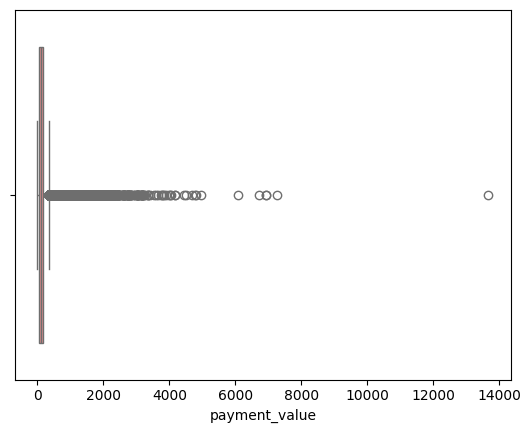

In [35]:
sns.boxplot(x=Payments["payment_value"], color="lightcoral")

Access the Reviews DataFrame

In [36]:
Reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB


In [37]:
Reviews.describe()

,review_score
count,99224.000000
mean,4.086421
std,1.347579
min,1.000000
25%,4.000000
50%,5.000000
75%,5.000000
max,5.000000


In [38]:
Reviews

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53
...,...,...,...,...,...,...,...
99219,574ed12dd733e5fa530cfd4bbf39d7c9,2a8c23fee101d4d5662fa670396eb8da,5,NaN,NaN,2018-07-07 00:00:00,2018-07-14 17:18:30
99220,f3897127253a9592a73be9bdfdf4ed7a,22ec9f0669f784db00fa86d035cf8602,5,NaN,NaN,2017-12-09 00:00:00,2017-12-11 20:06:42
99221,b3de70c89b1510c4cd3d0649fd302472,55d4004744368f5571d1f590031933e4,5,NaN,"Excelente mochila, entrega super rápida. Super...",2018-03-22 00:00:00,2018-03-23 09:10:43
99222,1adeb9d84d72fe4e337617733eb85149,7725825d039fc1f0ceb7635e3f7d9206,4,NaN,NaN,2018-07-01 00:00:00,2018-07-02 12:59:13


In [39]:
Reviews.isnull().sum()

review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64

In [40]:
Reviews_duplicate = Reviews[Reviews.duplicated()]
print(f"Number of duplicate rows: {Reviews_duplicate.shape[0]}")

Number of duplicate rows: 0


Access the Products DataFrame

In [41]:
Products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


In [42]:
Products.describe()

,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32341.000000,32341.000000,32341.000000,32949.000000,32949.000000,32949.000000,32949.000000
mean,48.476949,771.495285,2.188986,2276.472488,30.815078,16.937661,23.196728
std,10.245741,635.115225,1.736766,4282.038731,16.914458,13.637554,12.079047
min,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,42.000000,339.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,57.000000,972.000000,3.000000,1900.000000,38.000000,21.000000,30.000000
max,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000


In [43]:
# Check the decimal values in the attribute product_name_lenght
Products["product_name_lenght"].apply(
    lambda x: x != round(x) if pd.notnull(x) else False
).any()

np.False_

In [44]:
# Check the decimal values in the attribute product_description_lenght
Products["product_description_lenght"].apply(
    lambda x: x != round(x) if pd.notnull(x) else False
).any()

np.False_

In [45]:
Products["product_photos_qty"].apply(
    lambda x: x != round(x) if pd.notnull(x) else False
).any()

np.False_

In [46]:
Products["product_height_cm"].apply(
    lambda x: x != round(x) if pd.notnull(x) else False
).any()

np.False_

In [47]:
Products["product_width_cm"].apply(
    lambda x: x != round(x) if pd.notnull(x) else False
).any()

np.False_

In [48]:
Products["product_length_cm"].apply(
    lambda x: x != round(x) if pd.notnull(x) else False
).any()

np.False_

In [49]:
Products["product_weight_g"].apply(
    lambda x: x != round(x) if pd.notnull(x) else False
).any()

np.False_

In [50]:
Products.isnull().sum()

product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

In [51]:
Products_duplicate = Products[Products.duplicated()]
print(f"Number of duplicate rows: {Products_duplicate.shape[0]}")

Number of duplicate rows: 0


Access Product Category DataFrame

In [52]:
Category_name_translation.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   product_category_name          71 non-null     object
 1   product_category_name_english  71 non-null     object
dtypes: object(2)
memory usage: 1.2+ KB


In [53]:
Category_name_translation.describe()

,product_category_name,product_category_name_english
count,71,71
unique,71,71
top,beleza_saude,health_beauty
freq,1,1


In [54]:
Category_name_translation.isnull().sum()

product_category_name            0
product_category_name_english    0
dtype: int64

Access the Sellers DataFrame

In [55]:
Sellers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   seller_id               3095 non-null   object
 1   seller_zip_code_prefix  3095 non-null   int64 
 2   seller_city             3095 non-null   object
 3   seller_state            3095 non-null   object
dtypes: int64(1), object(3)
memory usage: 96.8+ KB


In [56]:
Sellers.isnull().sum()

seller_id                 0
seller_zip_code_prefix    0
seller_city               0
seller_state              0
dtype: int64

In [57]:
Sellers_duplicate = Sellers[Sellers.duplicated()]
print(f"Number of duplicate rows: {Sellers_duplicate.shape[0]}")

Number of duplicate rows: 0


Access the Geolocation DataFrame

In [58]:
Geo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1000163 non-null  object 
 4   geolocation_state            1000163 non-null  object 
dtypes: float64(2), int64(1), object(2)
memory usage: 38.2+ MB


In [59]:
Geo.isnull().sum()

geolocation_zip_code_prefix    0
geolocation_lat                0
geolocation_lng                0
geolocation_city               0
geolocation_state              0
dtype: int64

In [60]:
Geo_duplicate = Geo[Geo.duplicated()]
print(f"Number of duplicate rows: {Geo_duplicate.shape[0]}")

Number of duplicate rows: 261831


## Summary of Assessment  
### Table of Assessment Summary

| No | Table Name | Data Type | Missing Value | Duplicate Data | Inaccurate Value |
|----|-----------|-----------|---------------|----------------|------------------|
| 1 | customers | There is one invalid data type at column `customer_zip_code_prefix` | - | - | - |
| 2 | orders | There are five invalid data types starting from `order_purchase_timestamp` until `order_estimated_delivery_date` | There are three columns with missing values: `order_approved_at`, `order_delivered_carrier_date`, `order_delivered_customer_date` | - | - |
| 3 | order_items | There is one invalid data type in column `order_item_id` | - | Transform `order_item_id` into qty to extract unit-per-order line profile | There are outliers in column `price` and `freight_value` |
| 4 | order_payments | - | - | - | There is an outlier in column `payment_value` |
| 5 | order_reviews | There are two invalid data types at columns `review_creation_date` and `review_answer_timestamp` | There are two columns with missing values: `review_comment_title` and `review_comment_message` | - | - |
| 6 | products | There are seven columns that need type changes: `product_name_lenght`, `product_description_lenght`, `product_photos_qty`, `product_weight_g`, `product_length_cm`, `product_height_cm`, `product_width_cm` | There are eight columns with missing values: `product_category_name`, `product_name_lenght`, `product_description_lenght`, `product_photos_qty`, `product_weight_g`, `product_length_cm`, `product_height_cm`, `product_width_cm` | - | - |
| 7 | product_category_name | - | - | - | - |
| 8 | sellers | There is one invalid data type at column `seller_zip_code_prefix` | - | - | - |
| 9 | geolocation | There is one invalid data type at column `geolocation_zip_code_prefix` | - | Total duplicate values: **261,831** | - |


## Cleaning Data

### Customers DataFrame

In [61]:
# Change the customer_zip_code_prefix attribute to string
Customers_data["customer_zip_code_prefix"] = Customers_data[
    "customer_zip_code_prefix"
].astype(str)

# Check the data type of the customer_zip_code_prefix attribute
Customers_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  object
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: object(5)
memory usage: 3.8+ MB


### Orders DataFrame
We will be removing timestamp from dates column, they can cgrouped on the basis of days.

In [62]:
# Change the order_purchase_timestamp attribute to datetime
Orders["order_purchase_timestamp"] = pd.to_datetime(
    Orders["order_purchase_timestamp"]
)

# Change the order_approved_at attribute to datetime
Orders["order_approved_at"] = pd.to_datetime(Orders["order_approved_at"])

# Change the order_delivered_carrier_date attribute to datetime
Orders["order_delivered_carrier_date"] = pd.to_datetime(
    Orders["order_delivered_carrier_date"]
)

# Change the order_delivered_customer_date attribute to datetime
Orders["order_delivered_customer_date"] = pd.to_datetime(
    Orders["order_delivered_customer_date"]
)

# Change the order_estimated_delivery_date attribute to datetime
Orders["order_estimated_delivery_date"] = pd.to_datetime(
    Orders["order_estimated_delivery_date"]
)

# Check the data type of the attributes
Orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.1+ MB


In [63]:
# Define a function to convert the data type of a column to datetime
def convert_to_datetime(dataFrame, columns):
    for column in columns:
        dataFrame[column] = pd.to_datetime(dataFrame[column], format="%Y-%m-%d").dt.date

In [64]:
# Convert the data type of the attributes to datetime
convert_to_datetime(
    Orders,
    [
        "order_purchase_timestamp",
        "order_delivered_customer_date",
        "order_estimated_delivery_date",
    ],
)
Orders.sort_values(by=["order_purchase_timestamp"], inplace=True)

In [65]:
# Check the data type of the attributes
Orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
4541,2e7a8482f6fb09756ca50c10d7bfc047,08c5351a6aca1c1589a38f244edeee9d,shipped,2016-09-04,2016-10-07 13:18:03,2016-10-18 13:14:51,NaT,2016-10-20
4396,e5fa5a7210941f7d56d0208e4e071d35,683c54fc24d40ee9f8a6fc179fd9856c,canceled,2016-09-05,2016-10-07 13:17:15,NaT,NaT,2016-10-28
10071,809a282bbd5dbcabb6f2f724fca862ec,622e13439d6b5a0b486c435618b2679e,canceled,2016-09-13,2016-10-07 13:16:46,NaT,NaT,2016-09-30
30710,bfbd0f9bdef84302105ad712db648a6c,86dc2ffce2dfff336de2f386a786e574,delivered,2016-09-15,2016-09-15 12:16:38,2016-11-07 17:11:53,2016-11-09,2016-10-04
83078,71303d7e93b399f5bcd537d124c0bcfa,b106b360fe2ef8849fbbd056f777b4d5,canceled,2016-10-02,2016-10-06 15:50:56,NaT,NaT,2016-10-25


In [66]:
Orders.isnull().sum().sort_values(ascending=False)

order_delivered_customer_date    2965
order_delivered_carrier_date     1783
order_approved_at                 160
order_id                            0
order_purchase_timestamp            0
order_status                        0
customer_id                         0
order_estimated_delivery_date       0
dtype: int64

In [67]:
import importlib
import module.plotMissingValues
importlib.reload(module.plotMissingValues)
from module.plotMissingValues import percentage as pmv

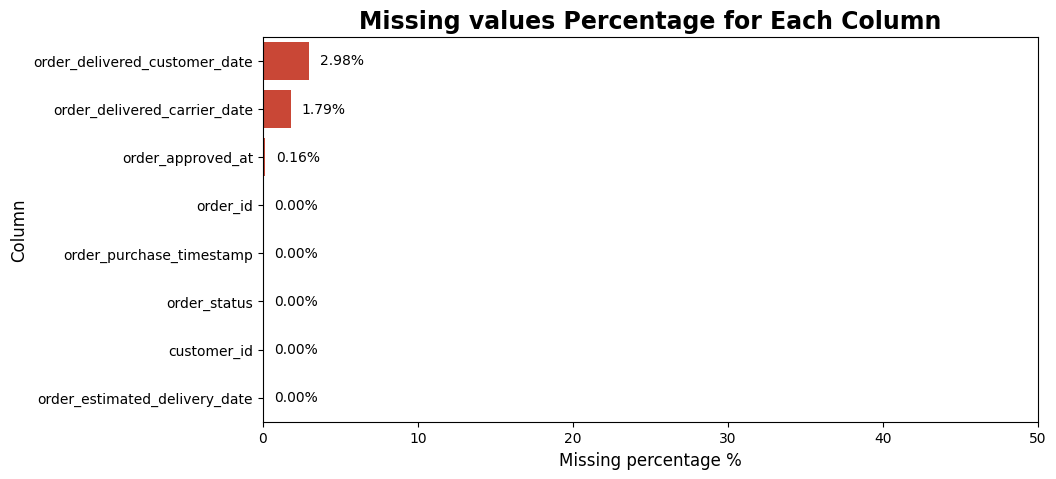

In [68]:
missing_percentage = pmv(Orders)

In [69]:
Orders['order_approved_at']= Orders['order_approved_at'].ffill()
Orders ['order_approved_at'].isnull().sum()

np.int64(0)

In [70]:
Orders[['order_approved_at','order_delivered_carrier_date']] = Orders[['order_approved_at','order_delivered_carrier_date']].ffill(axis=1)
Orders ['order_delivered_carrier_date'].isnull().sum()

np.int64(0)

In [71]:
Orders[['order_delivered_carrier_date','order_delivered_customer_date']] = Orders[['order_delivered_carrier_date','order_delivered_customer_date']].ffill(axis=1)
Orders ['order_delivered_customer_date'].isnull().sum()

C:\Users\adith\AppData\Local\Temp\ipykernel_25128\1827059615.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  Orders[['order_delivered_carrier_date','order_delivered_customer_date']] = Orders[['order_delivered_carrier_date','order_delivered_customer_date']].ffill(axis=1)


np.int64(0)

In [72]:
Orders['delivered_time'] = pd.to_datetime(Orders['order_delivered_customer_date'], format='%Y-%m-%d %H:%M:%S')
Orders['estimate_time'] = pd.to_datetime(Orders['order_estimated_delivery_date'], format='%Y-%m-%d %H:%M:%S')

In [73]:
Orders['weekly']=pd.to_datetime(Orders['order_delivered_customer_date'], format='%Y-%m-%d %H:%M:%S').dt.isocalendar().week

In [74]:
Orders

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivered_time,estimate_time,weekly
4541,2e7a8482f6fb09756ca50c10d7bfc047,08c5351a6aca1c1589a38f244edeee9d,shipped,2016-09-04,2016-10-07 13:18:03,2016-10-18 13:14:51,2016-10-18 13:14:51,2016-10-20,2016-10-18 13:14:51,2016-10-20,42
4396,e5fa5a7210941f7d56d0208e4e071d35,683c54fc24d40ee9f8a6fc179fd9856c,canceled,2016-09-05,2016-10-07 13:17:15,2016-10-07 13:17:15,2016-10-07 13:17:15,2016-10-28,2016-10-07 13:17:15,2016-10-28,40
10071,809a282bbd5dbcabb6f2f724fca862ec,622e13439d6b5a0b486c435618b2679e,canceled,2016-09-13,2016-10-07 13:16:46,2016-10-07 13:16:46,2016-10-07 13:16:46,2016-09-30,2016-10-07 13:16:46,2016-09-30,40
30710,bfbd0f9bdef84302105ad712db648a6c,86dc2ffce2dfff336de2f386a786e574,delivered,2016-09-15,2016-09-15 12:16:38,2016-11-07 17:11:53,2016-11-09,2016-10-04,2016-11-09 00:00:00,2016-10-04,45
83078,71303d7e93b399f5bcd537d124c0bcfa,b106b360fe2ef8849fbbd056f777b4d5,canceled,2016-10-02,2016-10-06 15:50:56,2016-10-06 15:50:56,2016-10-06 15:50:56,2016-10-25,2016-10-06 15:50:56,2016-10-25,40
...,...,...,...,...,...,...,...,...,...,...,...
50387,392ed9afd714e3c74767d0c4d3e3f477,2823ffda607a2316375088e0d00005ec,canceled,2018-09-29,2018-09-03 17:40:06,2018-09-03 17:40:06,2018-09-03 17:40:06,2018-10-15,2018-09-03 17:40:06,2018-10-15,36
88500,616fa7d4871b87832197b2a137a115d2,bf6181a85bbb4115736c0a8db1a53be3,canceled,2018-10-01,2018-09-03 17:40:06,2018-09-03 17:40:06,2018-09-03 17:40:06,2018-10-23,2018-09-03 17:40:06,2018-10-23,36
31891,a2ac6dad85cf8af5b0afb510a240fe8c,4c2ec60c29d10c34bd49cb88aa85cfc4,canceled,2018-10-03,2018-09-03 17:40:06,2018-09-03 17:40:06,2018-09-03 17:40:06,2018-10-16,2018-09-03 17:40:06,2018-10-16,36
68373,b059ee4de278302d550a3035c4cdb740,856336203359aa6a61bf3826f7d84c49,canceled,2018-10-16,2018-09-03 17:40:06,2018-09-03 17:40:06,2018-09-03 17:40:06,2018-11-12,2018-09-03 17:40:06,2018-11-12,36


In [75]:
# A column with ordinal order dates will also be included. This numerical format will ease further tasks.
# Adding a column with ordinal order dates
Orders["date_ordinal"] = Orders["order_purchase_timestamp"].apply(
    lambda date: date.toordinal()
)

In [76]:
Orders

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivered_time,estimate_time,weekly,date_ordinal
4541,2e7a8482f6fb09756ca50c10d7bfc047,08c5351a6aca1c1589a38f244edeee9d,shipped,2016-09-04,2016-10-07 13:18:03,2016-10-18 13:14:51,2016-10-18 13:14:51,2016-10-20,2016-10-18 13:14:51,2016-10-20,42,736211
4396,e5fa5a7210941f7d56d0208e4e071d35,683c54fc24d40ee9f8a6fc179fd9856c,canceled,2016-09-05,2016-10-07 13:17:15,2016-10-07 13:17:15,2016-10-07 13:17:15,2016-10-28,2016-10-07 13:17:15,2016-10-28,40,736212
10071,809a282bbd5dbcabb6f2f724fca862ec,622e13439d6b5a0b486c435618b2679e,canceled,2016-09-13,2016-10-07 13:16:46,2016-10-07 13:16:46,2016-10-07 13:16:46,2016-09-30,2016-10-07 13:16:46,2016-09-30,40,736220
30710,bfbd0f9bdef84302105ad712db648a6c,86dc2ffce2dfff336de2f386a786e574,delivered,2016-09-15,2016-09-15 12:16:38,2016-11-07 17:11:53,2016-11-09,2016-10-04,2016-11-09 00:00:00,2016-10-04,45,736222
83078,71303d7e93b399f5bcd537d124c0bcfa,b106b360fe2ef8849fbbd056f777b4d5,canceled,2016-10-02,2016-10-06 15:50:56,2016-10-06 15:50:56,2016-10-06 15:50:56,2016-10-25,2016-10-06 15:50:56,2016-10-25,40,736239
...,...,...,...,...,...,...,...,...,...,...,...,...
50387,392ed9afd714e3c74767d0c4d3e3f477,2823ffda607a2316375088e0d00005ec,canceled,2018-09-29,2018-09-03 17:40:06,2018-09-03 17:40:06,2018-09-03 17:40:06,2018-10-15,2018-09-03 17:40:06,2018-10-15,36,736966
88500,616fa7d4871b87832197b2a137a115d2,bf6181a85bbb4115736c0a8db1a53be3,canceled,2018-10-01,2018-09-03 17:40:06,2018-09-03 17:40:06,2018-09-03 17:40:06,2018-10-23,2018-09-03 17:40:06,2018-10-23,36,736968
31891,a2ac6dad85cf8af5b0afb510a240fe8c,4c2ec60c29d10c34bd49cb88aa85cfc4,canceled,2018-10-03,2018-09-03 17:40:06,2018-09-03 17:40:06,2018-09-03 17:40:06,2018-10-16,2018-09-03 17:40:06,2018-10-16,36,736970
68373,b059ee4de278302d550a3035c4cdb740,856336203359aa6a61bf3826f7d84c49,canceled,2018-10-16,2018-09-03 17:40:06,2018-09-03 17:40:06,2018-09-03 17:40:06,2018-11-12,2018-09-03 17:40:06,2018-11-12,36,736983


In [77]:
# Convert columns to date time
Orders["order_estimated_delivery_date"] = pd.to_datetime(
    Orders["order_estimated_delivery_date"]
)
Orders["order_delivered_customer_date"] = pd.to_datetime(
    Orders["order_delivered_customer_date"]
)
Orders["order_purchase_timestamp"] = pd.to_datetime(
    Orders["order_purchase_timestamp"]
)


# Create shipping time column, which is the difference between the order estimated delivery date and the order delivered customer date
Orders["shipping_time"] = (
    Orders["order_estimated_delivery_date"]
    - Orders["order_delivered_customer_date"]
)

# Create shipping duration column, which is the difference between the order delivered customer date and the order purchase timestamp
Orders["shipping_duration"] = (
    Orders["order_delivered_customer_date"] - Orders["order_purchase_timestamp"]
)

# Create estimated duration column, which is the difference between the order estimated delivery date and the order purchase timestamp
Orders["estimated_duration"] = (
    Orders["order_estimated_delivery_date"] - Orders["order_purchase_timestamp"]
)

In [78]:
Orders

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivered_time,estimate_time,weekly,date_ordinal,shipping_time,shipping_duration,estimated_duration
4541,2e7a8482f6fb09756ca50c10d7bfc047,08c5351a6aca1c1589a38f244edeee9d,shipped,2016-09-04,2016-10-07 13:18:03,2016-10-18 13:14:51,2016-10-18 13:14:51,2016-10-20,2016-10-18 13:14:51,2016-10-20,42,736211,1 days 10:45:09,44 days 13:14:51,46 days
4396,e5fa5a7210941f7d56d0208e4e071d35,683c54fc24d40ee9f8a6fc179fd9856c,canceled,2016-09-05,2016-10-07 13:17:15,2016-10-07 13:17:15,2016-10-07 13:17:15,2016-10-28,2016-10-07 13:17:15,2016-10-28,40,736212,20 days 10:42:45,32 days 13:17:15,53 days
10071,809a282bbd5dbcabb6f2f724fca862ec,622e13439d6b5a0b486c435618b2679e,canceled,2016-09-13,2016-10-07 13:16:46,2016-10-07 13:16:46,2016-10-07 13:16:46,2016-09-30,2016-10-07 13:16:46,2016-09-30,40,736220,-8 days +10:43:14,24 days 13:16:46,17 days
30710,bfbd0f9bdef84302105ad712db648a6c,86dc2ffce2dfff336de2f386a786e574,delivered,2016-09-15,2016-09-15 12:16:38,2016-11-07 17:11:53,2016-11-09 00:00:00,2016-10-04,2016-11-09 00:00:00,2016-10-04,45,736222,-36 days +00:00:00,55 days 00:00:00,19 days
83078,71303d7e93b399f5bcd537d124c0bcfa,b106b360fe2ef8849fbbd056f777b4d5,canceled,2016-10-02,2016-10-06 15:50:56,2016-10-06 15:50:56,2016-10-06 15:50:56,2016-10-25,2016-10-06 15:50:56,2016-10-25,40,736239,18 days 08:09:04,4 days 15:50:56,23 days
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50387,392ed9afd714e3c74767d0c4d3e3f477,2823ffda607a2316375088e0d00005ec,canceled,2018-09-29,2018-09-03 17:40:06,2018-09-03 17:40:06,2018-09-03 17:40:06,2018-10-15,2018-09-03 17:40:06,2018-10-15,36,736966,41 days 06:19:54,-26 days +17:40:06,16 days
88500,616fa7d4871b87832197b2a137a115d2,bf6181a85bbb4115736c0a8db1a53be3,canceled,2018-10-01,2018-09-03 17:40:06,2018-09-03 17:40:06,2018-09-03 17:40:06,2018-10-23,2018-09-03 17:40:06,2018-10-23,36,736968,49 days 06:19:54,-28 days +17:40:06,22 days
31891,a2ac6dad85cf8af5b0afb510a240fe8c,4c2ec60c29d10c34bd49cb88aa85cfc4,canceled,2018-10-03,2018-09-03 17:40:06,2018-09-03 17:40:06,2018-09-03 17:40:06,2018-10-16,2018-09-03 17:40:06,2018-10-16,36,736970,42 days 06:19:54,-30 days +17:40:06,13 days
68373,b059ee4de278302d550a3035c4cdb740,856336203359aa6a61bf3826f7d84c49,canceled,2018-10-16,2018-09-03 17:40:06,2018-09-03 17:40:06,2018-09-03 17:40:06,2018-11-12,2018-09-03 17:40:06,2018-11-12,36,736983,69 days 06:19:54,-43 days +17:40:06,27 days


In [79]:
# Check if there are repeating orders
print(f"Number of unique orders: {Orders['order_id'].nunique()}")
print(f"Number of records: {Orders.shape[0]}")

Number of unique orders: 99441
Number of records: 99441


## Order_items DataFrame 

In [80]:
# Change the order_item_id attribute to string
Order_items["order_item_id"] = Order_items["order_item_id"].astype(str)

# Check the data type of the attributes
Order_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  object 
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), object(5)
memory usage: 6.0+ MB


In [81]:
Order_items["price"].describe()

count    112650.000000
mean        120.653739
std         183.633928
min           0.850000
25%          39.900000
50%          74.990000
75%         134.900000
max        6735.000000
Name: price, dtype: float64

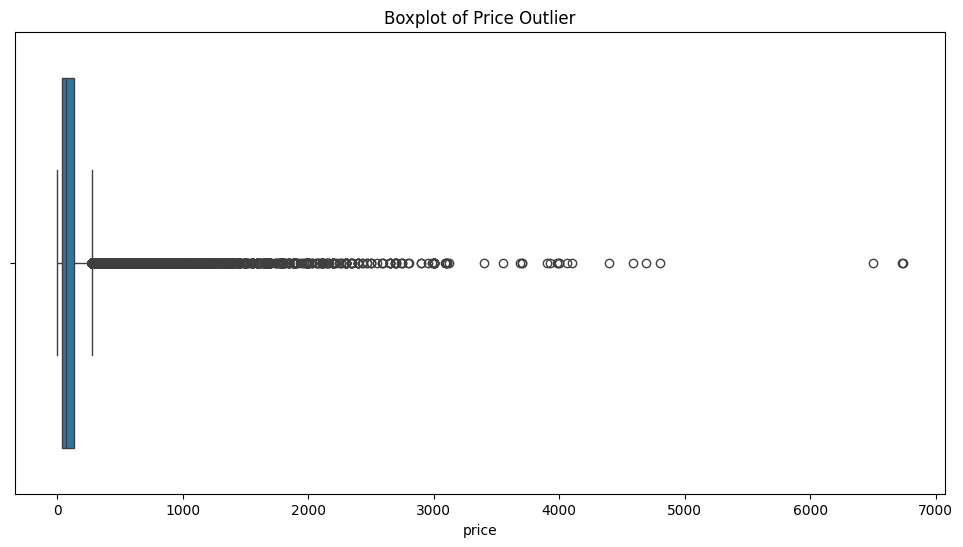

In [82]:
# Plot a boxplot to visualize outliers 
plt.figure(figsize=(12, 6))
sns.boxplot(x=Order_items["price"])
plt.title("Boxplot of Price Outlier")
plt.show()

In [83]:
# Handling Outliers in Price Attribute

# Calculate Q1, Q3, and IQR
Q1 = Order_items["price"].quantile(0.25)
Q3 = Order_items["price"].quantile(0.75)
IQR = Q3 - Q1

# Define bounds for the acceptable range
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Remove records with price outside the acceptable range
Order_items = Order_items[
    (Order_items["price"] >= lower_bound) & (Order_items["price"] <= upper_bound)
]

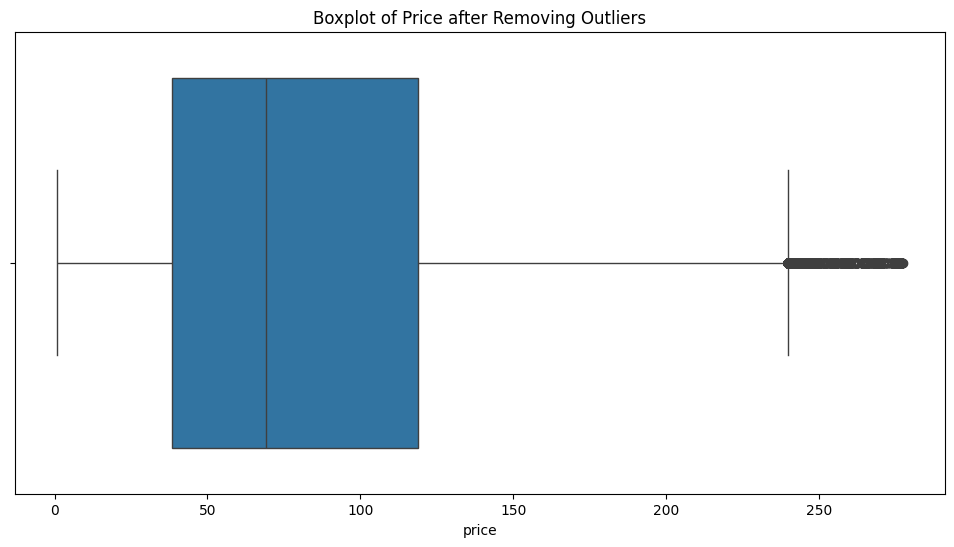

In [84]:
# Check the boxplot of the price attribute after removing outliers
plt.figure(figsize=(12, 6))
sns.boxplot(x=Order_items["price"])
plt.title("Boxplot of Price after Removing Outliers")
plt.show()

In [85]:
# Check the statistics of the price attribute after removing outliers
Order_items["price"].describe()

count    104223.000000
mean         83.974668
std          58.580002
min           0.850000
25%          38.500000
50%          69.000000
75%         118.990000
max         277.300000
Name: price, dtype: float64

In [86]:
# Check the statistics of the freight_value attribute before removing outliers
Order_items["freight_value"].describe()

count    104223.000000
mean         18.558853
std          12.049322
min           0.000000
25%          12.790000
50%          16.010000
75%          19.840000
max         299.160000
Name: freight_value, dtype: float64

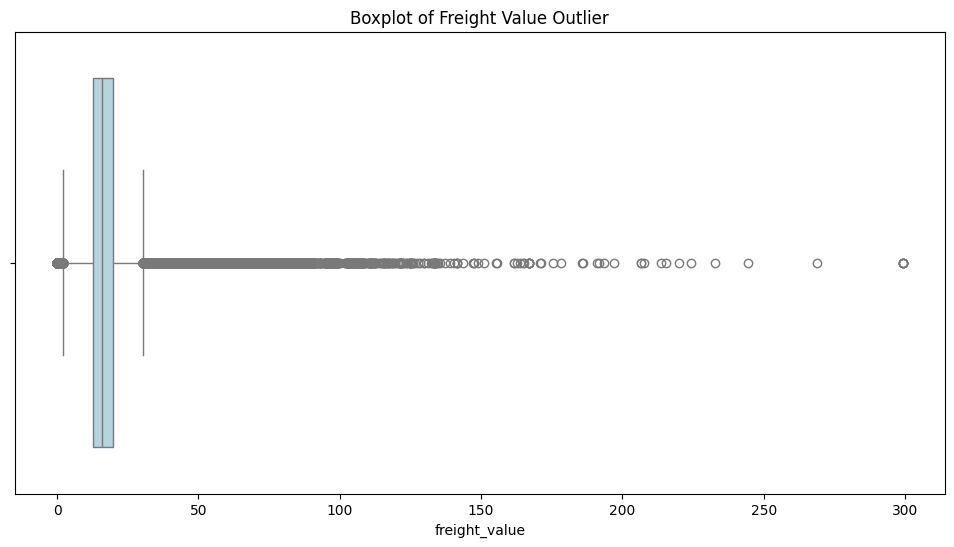

In [87]:
# Plot a boxplot to visualize the outliers
plt.figure(figsize=(12, 6))
sns.boxplot(x=Order_items["freight_value"], color="lightblue")
plt.title("Boxplot of Freight Value Outlier")
plt.show()

In [88]:
# Handling outliers of the freight_value attribute

# Handling outliers of the freight_value attribute

# Calculate Q1, Q3 and IQR
Q1 = Order_items["freight_value"].quantile(0.25)
Q3 = Order_items["freight_value"].quantile(0.75)
IQR = Q3 - Q1

# Define bounds for the acceptable range
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Remove rows with 'freight_value' outside the acceptable range
Order_items = Order_items[
    (Order_items["freight_value"] >= lower_bound)
    & (Order_items["freight_value"] <= upper_bound)
]

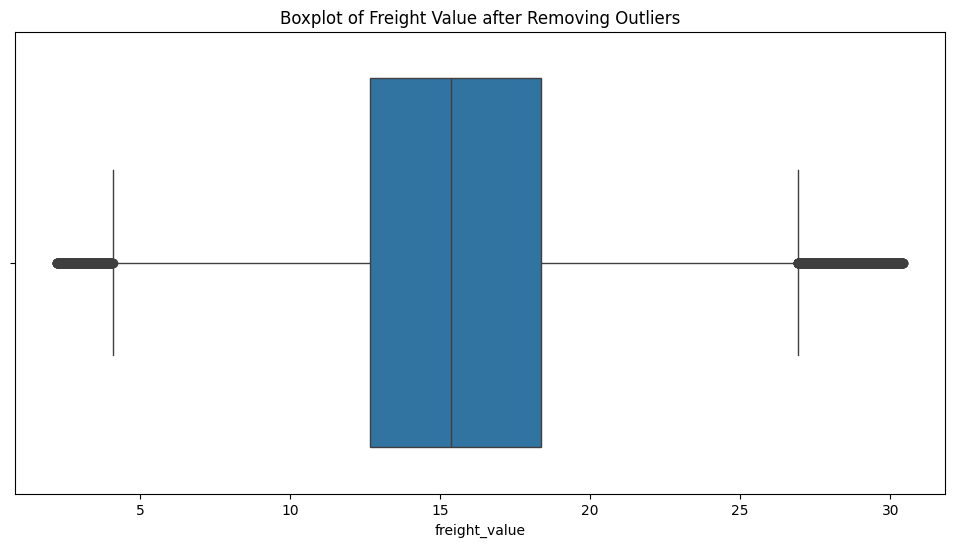

In [89]:
# Check the boxplot of the freight_value attribute after removing outliers
plt.figure(figsize=(12, 6))
sns.boxplot(x=Order_items["freight_value"])
plt.title("Boxplot of Freight Value after Removing Outliers")
plt.show()

In [90]:
# Check the statistics of the freight_value attribute after removing outliers
Order_items["freight_value"].describe()

count    93975.000000
mean        15.751864
std          5.113773
min          2.240000
25%         12.660000
50%         15.350000
75%         18.370000
max         30.410000
Name: freight_value, dtype: float64

In [91]:
Order_items_consolidated = (
    Order_items.groupby(by=["product_id", "order_id"])
    .agg(
        {
            "order_item_id": "count",
            "seller_id": "first",
            "shipping_limit_date": "first",
            "price": "first",
            "freight_value": "first",
        }
    )
    .reset_index()
)

Order_items_consolidated

,product_id,order_id,order_item_id,seller_id,shipping_limit_date,price,freight_value
0,00066f42aeeb9f3007548bb9d3f33c38,f30149f4a8882a08895b6a242aa0d612,1,5670f4db5b62c43d542e1b2d56b0cf7c,2018-05-24 18:58:59,101.65,18.59
1,00088930e925c41fd95ebfe695fd2655,f5eda0ded77c1293b04c953138c8331d,1,7142540dd4c91e2237acb7e911c4eba2,2017-12-18 19:32:19,129.90,13.93
2,0009406fd7479715e4bef61dd91f2462,0bf736fd0fd5169d60de3699fcbcf986,1,4a3ca9315b744ce9f8e9374361493884,2017-12-29 16:12:36,229.00,13.10
3,000b8f95fcb9e0096488278317764d19,3aba44d8e554ab4bb8c09f6f78032ca8,1,40ec8ab6cdafbcc4f544da38c67da39a,2018-08-16 13:35:21,58.90,19.60
4,000b8f95fcb9e0096488278317764d19,6f0dfb5b5398b271cc6bbd9ee263530e,1,40ec8ab6cdafbcc4f544da38c67da39a,2018-08-07 22:15:19,58.90,19.60
...,...,...,...,...,...,...,...
85049,fffdb2d0ec8d6a61f0a0a0db3f25b441,2878b4e373a9556df9aa1708a4e5c3c8,1,9f505651f4a6abe901a56cdc21508025,2018-08-09 16:55:38,34.99,7.51
85050,fffdb2d0ec8d6a61f0a0a0db3f25b441,a8159270bc9cf7d54450e079ba6b7232,1,9f505651f4a6abe901a56cdc21508025,2018-04-09 05:35:27,29.99,18.23
85051,fffdb2d0ec8d6a61f0a0a0db3f25b441,beaf95465b542dea76df78b2fb86a97a,1,9f505651f4a6abe901a56cdc21508025,2018-04-25 10:30:35,34.99,18.23
85052,fffdb2d0ec8d6a61f0a0a0db3f25b441,d6c1ed12e8eeaa15e9d5c83c79598f85,1,9f505651f4a6abe901a56cdc21508025,2018-08-14 17:25:18,34.99,7.51


In [92]:
# Checking is there any info was lost
print(f"Orders in new table: {Order_items_consolidated['order_id'].nunique()}")
print(f"Orders in old table: {Order_items['order_id'].nunique()}")
print(f"SKUs in new table: {Order_items_consolidated['product_id'].nunique()}")
print(f"SKUs in old table: {Order_items['product_id'].nunique()}")
print(
    f"Total quantity in new table: {Order_items_consolidated['order_item_id'].sum()}"
)
print(f"Total quantity in old table: {len(Order_items['order_item_id'])}")

Orders in new table: 82186
Orders in old table: 82186
SKUs in new table: 27336
SKUs in old table: 27336
Total quantity in new table: 93975
Total quantity in old table: 93975


In [93]:
# Renaming the order_item_id column to quantity
Order_items_consolidated.rename(columns={"order_item_id": "qty"}, inplace=True)
Order_items_consolidated

,product_id,order_id,qty,seller_id,shipping_limit_date,price,freight_value
0,00066f42aeeb9f3007548bb9d3f33c38,f30149f4a8882a08895b6a242aa0d612,1,5670f4db5b62c43d542e1b2d56b0cf7c,2018-05-24 18:58:59,101.65,18.59
1,00088930e925c41fd95ebfe695fd2655,f5eda0ded77c1293b04c953138c8331d,1,7142540dd4c91e2237acb7e911c4eba2,2017-12-18 19:32:19,129.90,13.93
2,0009406fd7479715e4bef61dd91f2462,0bf736fd0fd5169d60de3699fcbcf986,1,4a3ca9315b744ce9f8e9374361493884,2017-12-29 16:12:36,229.00,13.10
3,000b8f95fcb9e0096488278317764d19,3aba44d8e554ab4bb8c09f6f78032ca8,1,40ec8ab6cdafbcc4f544da38c67da39a,2018-08-16 13:35:21,58.90,19.60
4,000b8f95fcb9e0096488278317764d19,6f0dfb5b5398b271cc6bbd9ee263530e,1,40ec8ab6cdafbcc4f544da38c67da39a,2018-08-07 22:15:19,58.90,19.60
...,...,...,...,...,...,...,...
85049,fffdb2d0ec8d6a61f0a0a0db3f25b441,2878b4e373a9556df9aa1708a4e5c3c8,1,9f505651f4a6abe901a56cdc21508025,2018-08-09 16:55:38,34.99,7.51
85050,fffdb2d0ec8d6a61f0a0a0db3f25b441,a8159270bc9cf7d54450e079ba6b7232,1,9f505651f4a6abe901a56cdc21508025,2018-04-09 05:35:27,29.99,18.23
85051,fffdb2d0ec8d6a61f0a0a0db3f25b441,beaf95465b542dea76df78b2fb86a97a,1,9f505651f4a6abe901a56cdc21508025,2018-04-25 10:30:35,34.99,18.23
85052,fffdb2d0ec8d6a61f0a0a0db3f25b441,d6c1ed12e8eeaa15e9d5c83c79598f85,1,9f505651f4a6abe901a56cdc21508025,2018-08-14 17:25:18,34.99,7.51


## Order Payment Table


In [94]:
# Check the statistics of the payment_value attribute before removing outliers
Payments["payment_value"].describe()

count    103886.000000
mean        154.100380
std         217.494064
min           0.000000
25%          56.790000
50%         100.000000
75%         171.837500
max       13664.080000
Name: payment_value, dtype: float64

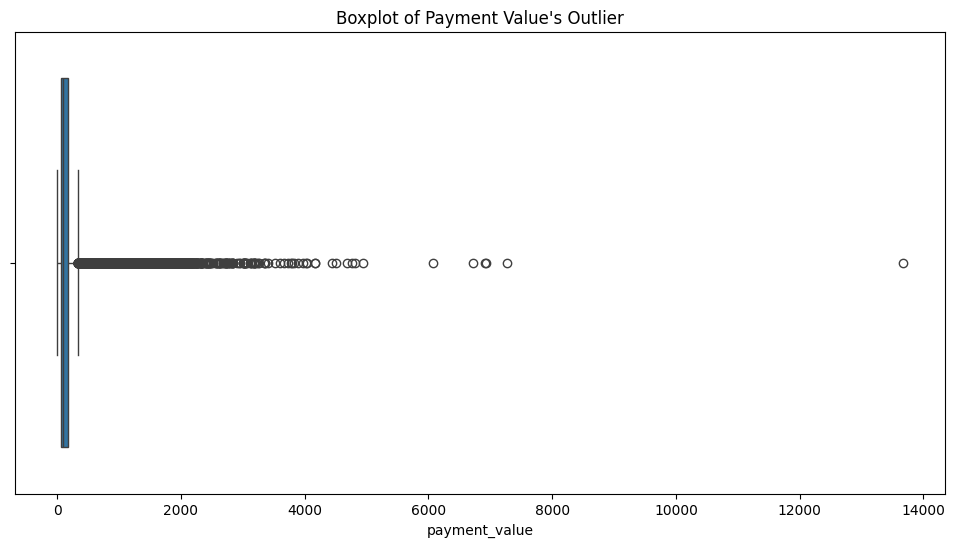

In [95]:
# Plot a boxplot to visualize the outliers
plt.figure(figsize=(12, 6))
sns.boxplot(x=Payments["payment_value"])
plt.title("Boxplot of Payment Value's Outlier")
plt.show()

In [96]:
# Handling outliers of the payment_value attribute

# Handling outliers of the payment_value attribute

# Calculate Q1, Q3 and IQR
Q1 = Payments["payment_value"].quantile(0.25)
Q3 = Payments["payment_value"].quantile(0.75)
IQR = Q3 - Q1

# Define bounds for the acceptable range
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Remove rows with 'payment_value' outside the acceptable range
Payments = Payments[
    (Payments["payment_value"] >= lower_bound)
    & (Payments["payment_value"] <= upper_bound)
]

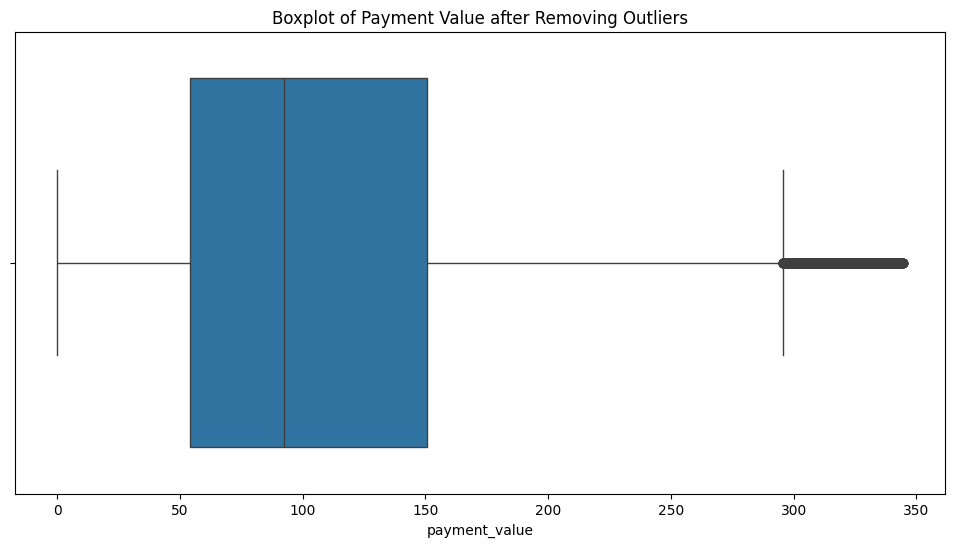

In [97]:
# Plot a boxplot of the payment_value attribute after removing outliers
plt.figure(figsize=(12, 6))
sns.boxplot(x = Payments["payment_value"])
plt.title("Boxplot of Payment Value after Removing Outliers")
plt.show()

In [98]:
# Check the statistics of the payment_value attribute after removing outliers
Payments["payment_value"].describe()

count    95905.000000
mean       110.062133
std         72.785054
min          0.000000
25%         54.000000
50%         92.200000
75%        150.580000
max        344.340000
Name: payment_value, dtype: float64

## Order Reviews DataFrame

In [99]:
Reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB


In [100]:
# Change the review_creation_date attribute to datetime
Reviews["review_creation_date"] = pd.to_datetime(
    Reviews["review_creation_date"]
)

# Change the review_answer_timestamp attribute to datetime
Reviews["review_answer_timestamp"] = pd.to_datetime(
    Reviews["review_answer_timestamp"]
)

# Check the data type of the attributes
Reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   review_id                99224 non-null  object        
 1   order_id                 99224 non-null  object        
 2   review_score             99224 non-null  int64         
 3   review_comment_title     11568 non-null  object        
 4   review_comment_message   40977 non-null  object        
 5   review_creation_date     99224 non-null  datetime64[ns]
 6   review_answer_timestamp  99224 non-null  datetime64[ns]
dtypes: datetime64[ns](2), int64(1), object(4)
memory usage: 5.3+ MB


In [101]:
Reviews

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01,2018-03-02 10:26:53
...,...,...,...,...,...,...,...
99219,574ed12dd733e5fa530cfd4bbf39d7c9,2a8c23fee101d4d5662fa670396eb8da,5,NaN,NaN,2018-07-07,2018-07-14 17:18:30
99220,f3897127253a9592a73be9bdfdf4ed7a,22ec9f0669f784db00fa86d035cf8602,5,NaN,NaN,2017-12-09,2017-12-11 20:06:42
99221,b3de70c89b1510c4cd3d0649fd302472,55d4004744368f5571d1f590031933e4,5,NaN,"Excelente mochila, entrega super rápida. Super...",2018-03-22,2018-03-23 09:10:43
99222,1adeb9d84d72fe4e337617733eb85149,7725825d039fc1f0ceb7635e3f7d9206,4,NaN,NaN,2018-07-01,2018-07-02 12:59:13


In [102]:
# Backup the dataset order_reviews_df
order_reviews_cleaned_df = Reviews.copy()

In [103]:
order_reviews_cleaned_df.isnull().sum().sort_values(ascending=False)

review_comment_title       87656
review_comment_message     58247
review_id                      0
review_score                   0
order_id                       0
review_creation_date           0
review_answer_timestamp        0
dtype: int64

In [104]:
# Fill the missing values in review_comment_title with "No comment"
order_reviews_cleaned_df["review_comment_title"].fillna("No comment", inplace=True)

# Fill the missing values in review_comment_message with "No comment"
order_reviews_cleaned_df["review_comment_message"].fillna("No comment", inplace=True)

# Check the missing values again
print(f"Missing values: {order_reviews_cleaned_df.isnull().sum().sum()}")

Missing values: 0


In [105]:
# Merge the dataframes order_reviews that filled the missing values with the missing values of the original dataframe
order_reviews_df = pd.merge(
    order_reviews_cleaned_df, Reviews, how="left"
).copy()
order_reviews_cleaned_df.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,No comment,No comment,2018-01-18,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,No comment,No comment,2018-03-10,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,No comment,No comment,2018-02-17,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,No comment,Recebi bem antes do prazo estipulado.,2017-04-21,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,No comment,Parabéns lojas lannister adorei comprar pela I...,2018-03-01,2018-03-02 10:26:53


### Products DataFrame

In [106]:
Products.rename(columns={"product_description_lenght": "product_description_length"}, inplace=True)
Products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_length  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


In [107]:
# Change the product_name_lenght attribute to product_name_length
Products.rename(columns={"product_name_lenght": "product_name_length"}, inplace=True)
Products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_length         32341 non-null  float64
 3   product_description_length  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


In [108]:
Products.isnull().sum()

product_id                      0
product_category_name         610
product_name_length           610
product_description_length    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

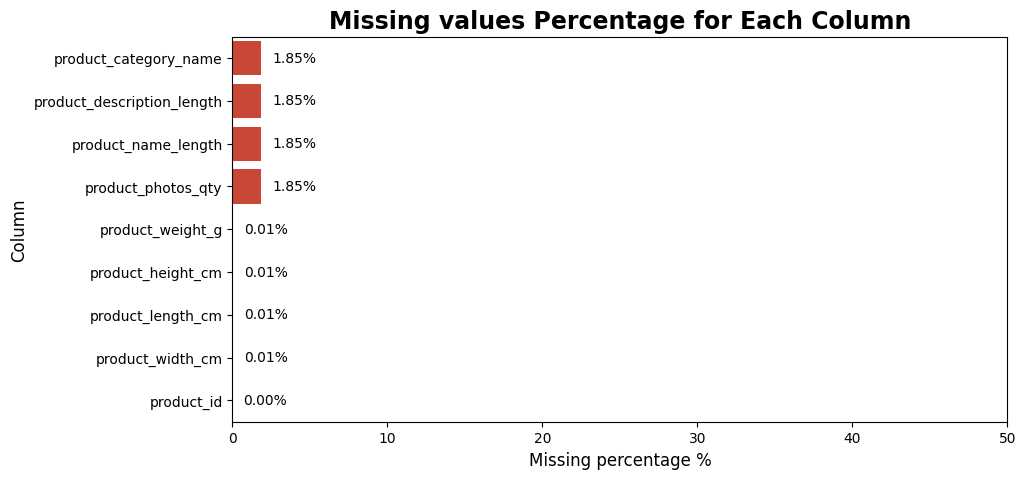

In [109]:
Products_missing_percentage = pmv(Products)

In [110]:
# Check the unique values of the product_category_name attribute
print(f"Number of unique values:\n {Products['product_category_name'].unique()}")

Number of unique values:
 ['perfumaria' 'artes' 'esporte_lazer' 'bebes' 'utilidades_domesticas'
 'instrumentos_musicais' 'cool_stuff' 'moveis_decoracao'
 'eletrodomesticos' 'brinquedos' 'cama_mesa_banho'
 'construcao_ferramentas_seguranca' 'informatica_acessorios'
 'beleza_saude' 'malas_acessorios' 'ferramentas_jardim'
 'moveis_escritorio' 'automotivo' 'eletronicos' 'fashion_calcados'
 'telefonia' 'papelaria' 'fashion_bolsas_e_acessorios' 'pcs'
 'casa_construcao' 'relogios_presentes'
 'construcao_ferramentas_construcao' 'pet_shop' 'eletroportateis'
 'agro_industria_e_comercio' nan 'moveis_sala' 'sinalizacao_e_seguranca'
 'climatizacao' 'consoles_games' 'livros_interesse_geral'
 'construcao_ferramentas_ferramentas' 'fashion_underwear_e_moda_praia'
 'fashion_roupa_masculina'
 'moveis_cozinha_area_de_servico_jantar_e_jardim'
 'industria_comercio_e_negocios' 'telefonia_fixa'
 'construcao_ferramentas_iluminacao' 'livros_tecnicos'
 'eletrodomesticos_2' 'artigos_de_festas' 'bebidas' 'market_p

In [111]:
print(
    f"Frequency of each value in product_category_name attribute:\n {Products['product_category_name'].value_counts()}"
)

Frequency of each value in product_category_name attribute:
 product_category_name
cama_mesa_banho                  3029
esporte_lazer                    2867
moveis_decoracao                 2657
beleza_saude                     2444
utilidades_domesticas            2335
                                 ... 
fashion_roupa_infanto_juvenil       5
casa_conforto_2                     5
pc_gamer                            3
seguros_e_servicos                  2
cds_dvds_musicais                   1
Name: count, Length: 73, dtype: int64


In [112]:
# Find the mode of the product_category_name attribute
mode_pcn = Products["product_category_name"].mode()[0]

# Fill the missing values in product_category_name with the mode
Products["product_category_name"].fillna(mode_pcn, inplace=True)

<Axes: xlabel='product_name_length', ylabel='Count'>

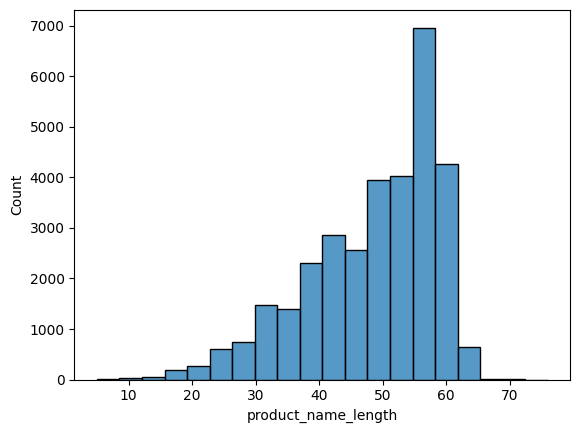

In [113]:
# Plot the distribution values of the product_name_length attribute
sns.histplot(data=Products, x="product_name_length", bins=20)

<Axes: xlabel='product_description_length', ylabel='Count'>

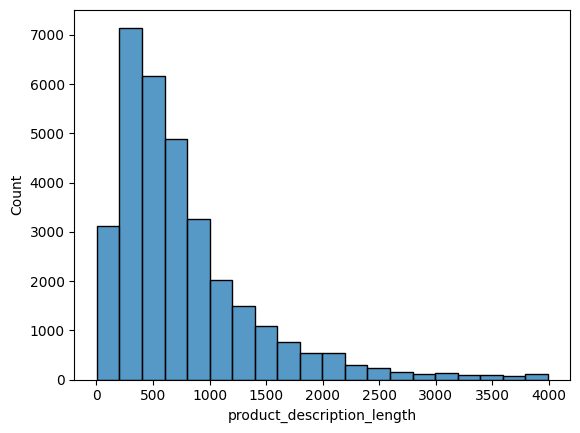

In [114]:
# Plot the distribution values of the product_description_length attribute
sns.histplot(data=Products, x="product_description_length", bins=20)

<Axes: xlabel='product_photos_qty', ylabel='Count'>

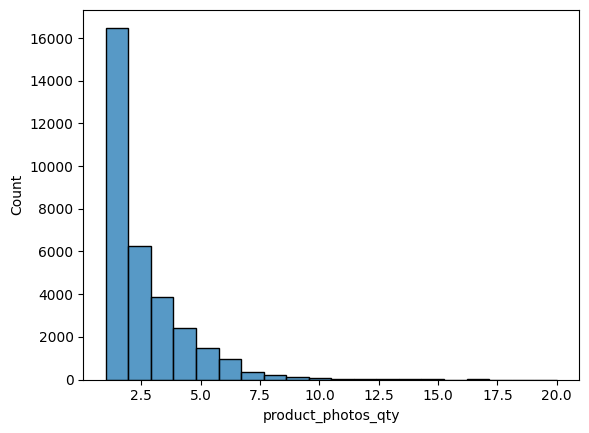

In [115]:
# Plot the distribution values of the product_photos_qty attribute
sns.histplot(data=Products, x="product_photos_qty", bins=20)

<Axes: xlabel='product_weight_g', ylabel='Count'>

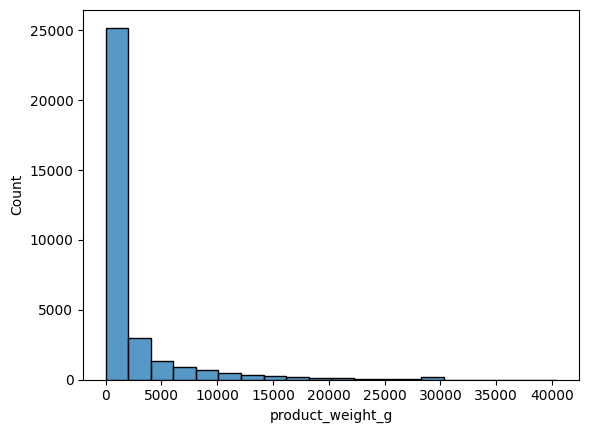

In [116]:
# Plot the distribution values of the product_weight_g attribute
sns.histplot(data=Products, x="product_weight_g", bins=20)

<Axes: xlabel='product_length_cm', ylabel='Count'>

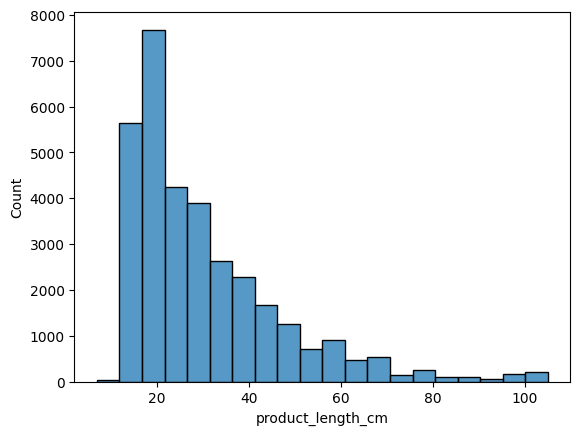

In [117]:
# Plot the distribution values of the product_length_cm attribute
sns.histplot(data=Products, x="product_length_cm", bins=20)

<Axes: xlabel='product_height_cm', ylabel='Count'>

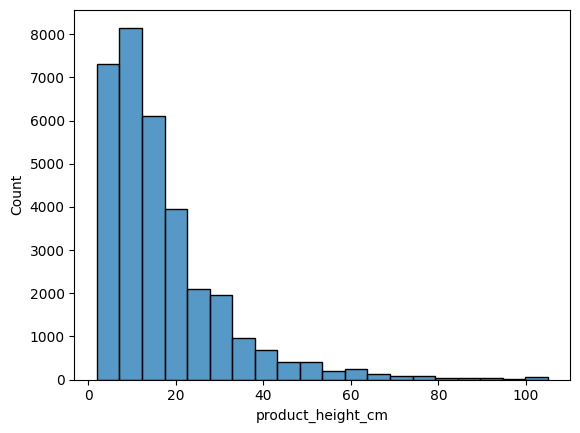

In [118]:
# Plot the distribution values of the product_height_cm attribute
sns.histplot(data=Products, x="product_height_cm", bins=20)

<Axes: xlabel='product_width_cm', ylabel='Count'>

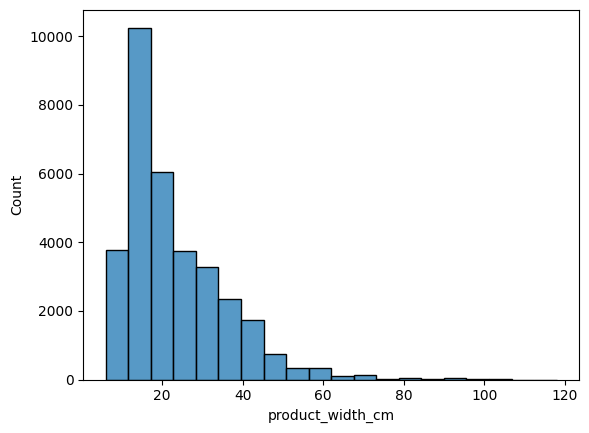

In [119]:
# Plot the distribution values of the product_width_cm attribute
sns.histplot(data=Products, x="product_width_cm", bins=20)

In [120]:
"""
Find the median values for the following attributes:
- product_name_length
- product_description_length
- product_photos_qty
- product_weight_g
- product_length_cm
- product_height_cm
- product_width_cm
"""
median_pnl = Products["product_name_length"].median()
median_pdl = Products["product_description_length"].median()
median_ppq = Products["product_photos_qty"].median()
median_pw = Products["product_weight_g"].median()
median_pl = Products["product_length_cm"].median()
median_ph = Products["product_height_cm"].median()
median_pw = Products["product_width_cm"].median()

# Fill the missing values with the median

Products["product_name_length"].fillna(median_pnl, inplace=True)
Products["product_description_length"].fillna(median_pdl, inplace=True)
Products["product_photos_qty"].fillna(median_ppq, inplace=True)
Products["product_weight_g"].fillna(median_pw, inplace=True)
Products["product_length_cm"].fillna(median_pl, inplace=True)
Products["product_height_cm"].fillna(median_ph, inplace=True)
Products["product_width_cm"].fillna(median_pw, inplace=True)

In [121]:
# Check the missing values again
print(f"Missing values: {Products.isnull().sum().sum()}")

Missing values: 0


In [122]:
# Change the datatype of the product_name_length attribute to int
Products["product_name_length"] = Products["product_name_length"].astype(int)

# Change the datatype of the product_description_length attribute to int
Products["product_description_length"] = Products[
    "product_description_length"
].astype(int)

# Change the datatype of the product_photos_qty attribute to int
Products["product_photos_qty"] = Products["product_photos_qty"].astype(int)

# Change the datatype of the product_weight_g attribute to int
Products["product_weight_g"] = Products["product_weight_g"].astype(int)

# Change the datatype of the product_length_cm attribute to int
Products["product_length_cm"] = Products["product_length_cm"].astype(int)

# Change the datatype of the product_height_cm attribute to int
Products["product_height_cm"] = Products["product_height_cm"].astype(int)

# Change the datatype of the product_width_cm attribute to int
Products["product_width_cm"] = Products["product_width_cm"].astype(int)

In [123]:
Products.head()

,product_id,product_category_name,product_name_length,product_description_length,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40,287,1,225,16,10,14
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44,276,1,1000,30,18,20
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46,250,1,154,18,9,15
3,cef67bcfe19066a932b7673e239eb23d,bebes,27,261,1,371,26,4,26
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37,402,4,625,20,17,13


### Sellers DataFrame

In [124]:
Sellers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   seller_id               3095 non-null   object
 1   seller_zip_code_prefix  3095 non-null   int64 
 2   seller_city             3095 non-null   object
 3   seller_state            3095 non-null   object
dtypes: int64(1), object(3)
memory usage: 96.8+ KB


In [126]:
# Change the seller_zip_code_prefix attribute to string
Sellers["seller_zip_code_prefix"] = Sellers["seller_zip_code_prefix"].astype(str)

# Check the data type of the seller_zip_code_prefix attribute
Sellers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   seller_id               3095 non-null   object
 1   seller_zip_code_prefix  3095 non-null   object
 2   seller_city             3095 non-null   object
 3   seller_state            3095 non-null   object
dtypes: object(4)
memory usage: 96.8+ KB


Geolocation DataFrame

In [127]:
# Change the geolocation_zip_code_prefix attribute to string
Geo["geolocation_zip_code_prefix"] = Geo[
    "geolocation_zip_code_prefix"
].astype(str)

# Check the data type of the geolocation_zip_code_prefix attribute
Geo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  object 
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1000163 non-null  object 
 4   geolocation_state            1000163 non-null  object 
dtypes: float64(2), object(3)
memory usage: 38.2+ MB


In [129]:
# Drop the duplicate values in the geolocation_df
Geo.drop_duplicates(
    subset=["geolocation_zip_code_prefix"], keep="first", inplace=True
)

# Check the duplicate values in the geolocation_df
duplicate_value = Geo.duplicated()
print(f"Total duplicate value: {duplicate_value.sum()}")

Total duplicate value: 0


In [130]:
# Check unique data in attribute geolocation_city
print(f"Number of unique values:\n {Geo['geolocation_city'].unique()}")

Number of unique values:
 ['sao paulo' 'são paulo' 'osasco' ... 'floriano peixoto' 'erebango'
 'santa cecilia do sul']


In [131]:
# Check the frequency of each value in attribute geolocation_city
Geo.groupby(by=["geolocation_city", "geolocation_zip_code_prefix"]).agg(
    {"geolocation_city": "count"}
)

,,geolocation_city
geolocation_city,geolocation_zip_code_prefix,
abadia de goias,75345,1
abadia dos dourados,38540,1
abadiania,72940,1
abaete,35620,1
abaetetuba,68440,1
...,...,...
águas lindas de goiás,72927,1
álvaro de carvalho,17410,1
ângulo,86755,1


In [132]:
Geo.groupby(by=["geolocation_city", "geolocation_zip_code_prefix"]).agg(
    {"geolocation_city": "nunique"}
)

,,geolocation_city
geolocation_city,geolocation_zip_code_prefix,
abadia de goias,75345,1
abadia dos dourados,38540,1
abadiania,72940,1
abaete,35620,1
abaetetuba,68440,1
...,...,...
águas lindas de goiás,72927,1
álvaro de carvalho,17410,1
ângulo,86755,1


In [133]:
# Data homogenization
Geo.geolocation_city = Geo.geolocation_city.apply(
    lambda x: "abadiânia" if x == "abadiania" else x
)
Geo.geolocation_city = Geo.geolocation_city.apply(
    lambda x: "abaeté" if x == "abaete" else x
)
Geo.geolocation_city = Geo.geolocation_city.apply(
    lambda x: "abaré" if x == "abare" else x
)
Geo.geolocation_city = Geo.geolocation_city.apply(
    lambda x: "abatiá" if x == "abatia" else x
)
Geo.geolocation_city = Geo.geolocation_city.apply(
    lambda x: "são paulo" if x == "sao paulo" else x
)
Geo.geolocation_city = Geo.geolocation_city.apply(
    lambda x: "cidade gaúcha" if x == "cidade" else x
)
Geo.geolocation_city = Geo.geolocation_city.apply(
    lambda x: "arraial do cabo" if x == "...arraial do cabo" else x
)
Geo.geolocation_city = Geo.geolocation_city.apply(
    lambda x: "quarto centenário" if x == "4o. centenario" else x
)
Geo.geolocation_city = Geo.geolocation_city.apply(
    lambda x: "quarto centenário" if x == "4º centenario" else x
)
Geo.geolocation_city = Geo.geolocation_city.apply(
    lambda x: "quarto centenário" if x == "quarto centenario" else x
)

In [134]:
Geo.geolocation_city.unique()

array(['são paulo', 'osasco', 'carapicuíba', ..., 'floriano peixoto',
       'erebango', 'santa cecilia do sul'], shape=(5954,), dtype=object)